In [250]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [251]:
import numpy as np
import matplotlib.pyplot as plt

In [252]:
from simulators import ContextManager, NestedModelFamily
from simulators.benchmarks import DDM
from simulators.benchmarks.ddms import sample_ddm_prior

In [254]:
num_samples = 2000

In [255]:
def sample_num_conditions():
    return np.random.choice(np.arange(4))

def sample_design_config(num_conditions: int):
    config = np.zeros((num_conditions + 1, 6))
    config[0, 0:3] = 1  # intercept row covers v, a, tau
    config[0, 3:] = np.random.randint(2, size=3)
    if num_conditions > 0:
        for i in range(num_conditions):
            for j in range(6):
                if config[0, j] == 1.0:
                    config[i + 1, j] = np.random.randint(2)
    return config

In [256]:
intrinsic_params = ["v", "a", "tau", "s_v", "s_tau", "decay"]

In [257]:
num_conditions = sample_num_conditions()
binary_mask = sample_design_config(num_conditions)

# Convert binary mask → design_config dict format
# Row 0 = intercept, rows >0 = slopes
design_config = {}
for row_index in range(binary_mask.shape[0]):
    affected = [intrinsic_params[j] for j in range(binary_mask.shape[1]) if binary_mask[row_index, j] == 1.0]
    design_key = "1" if row_index == 0 else f"u_{row_index}"
    design_config[design_key] = affected

print("Design Config:", design_config)

Design Config: {'1': ['v', 'a', 'tau', 'decay'], 'u_1': ['v', 'a', 'tau'], 'u_2': ['a']}


In [258]:
# Priors: intercept vs slope samplers per intrinsic
priors = {
    "v":     {"intercept": lambda: np.random.gamma(3.0, 0.8),
              "slope":     lambda: np.random.normal(0.0, 3.0)},
    "a":     {"intercept": lambda: np.random.gamma(10.0, 0.3),
              "slope":     lambda: np.random.normal(0.0, 1.0)},
    "tau":   {"intercept": lambda: np.random.gamma(3.0, 0.2),
              "slope":     lambda: 0.0},
    "s_v":   {"intercept": lambda: np.random.gamma(1.0, 0.2),
              "slope":     lambda: 0.0},
    "s_tau": {"intercept": lambda: np.random.uniform(0.0, 0.4),
              "slope":     lambda: 0.0},
    "decay": {"intercept": lambda: np.random.gamma(1.0, 0.4),
              "slope":     lambda: 0.0},
}

In [259]:
cm = ContextManager(parameter_names=[])  # not used in full-regression path
family = NestedModelFamily(
    name="DDM",
    model=DDM,
    context_manager=cm,
    prior_fun=sample_ddm_prior,   # kept for legacy path; unused here
    num_samples=num_samples,
)

In [260]:
out = family.sample_with_design(
    design_config=design_config,
    intrinsic_names=intrinsic_params,
    priors=priors,
    num_samples=num_samples,
)

In [261]:
design_matrix     = out["design_matrix"]
parameter_mask    = out["parameter_mask"]
parameter_matrix  = out["parameter_matrix"]
params_for_model  = out["params"]
sim_data          = out["sim_data"]

In [262]:
parameter_mask

array([[1., 1., 1., 0., 0., 1.],
       [1., 1., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.]], dtype=float32)

In [263]:
parameter_matrix

array([[ 2.2550373 ,  2.9490302 ,  1.0679567 ,  0.        ,  0.        ,
         0.11843422],
       [-3.2472107 ,  1.0515101 ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [ 0.        ,  0.00538552,  0.        ,  0.        ,  0.        ,
         0.        ]], dtype=float32)

In [264]:
sim_data

{'rts': array([4.127957 , 1.7179567, 3.6759567, ..., 5.279957 , 2.2599566,
        1.4539567], shape=(2000,), dtype=float32),
 'choices': array([0., 1., 1., ..., 0., 1., 1.], shape=(2000,), dtype=float32)}

In [249]:
print("design_matrix shape        :", design_matrix.shape)        # (N, K)
print("parameter_mask shape       :", parameter_mask.shape)       # (K, M)
print("parameter_matrix shape     :", parameter_matrix.shape)     # (K, M)

design_matrix shape        : (2000, 2)
parameter_mask shape       : (2, 6)
parameter_matrix shape     : (2, 6)


In [50]:
design_matrix

array([[1.        , 0.25069326, 0.        , 0.509511  ],
       [1.        , 0.2596343 , 0.        , 0.5013285 ],
       [1.        , 0.9946695 , 0.        , 0.8696891 ],
       ...,
       [1.        , 0.05285838, 1.        , 0.83525413],
       [1.        , 0.8080384 , 0.        , 0.8829516 ],
       [1.        , 0.5945604 , 0.        , 0.12550305]],
      shape=(2000, 4), dtype=float32)

In [265]:
intrinsic_values_matrix = (design_matrix @ parameter_matrix).astype(np.float32)
assert intrinsic_values_matrix.shape == (num_samples, len(intrinsic_params))

In [52]:
col_idx = {name: j for j, name in enumerate(intrinsic_params)}
v_arr = params_for_model["v"]
a_arr = params_for_model["a"]
assert np.allclose(v_arr, intrinsic_values_matrix[:, col_idx["v"]])
assert np.allclose(a_arr, intrinsic_values_matrix[:, col_idx["a"]])

In [53]:
intercepts = out["params"].get("_intercepts", {})
print("Intercepts:", {k: round(v, 4) for k, v in intercepts.items()})

Intercepts: {}


In [16]:
rts = sim_data["rts"]
choices = sim_data["choices"]
print("Simulated RTs:", np.nanmin(rts[rts>0]), "→", np.nanmax(rts))
print("Choice rate (mean):", np.mean(choices))

Simulated RTs: 0.625491 → 10.471491
Choice rate (mean): 0.845


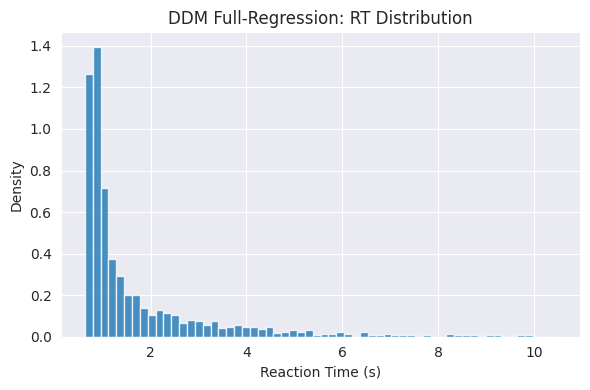

In [17]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(rts[rts > 0], bins=60, density=True, alpha=0.8)
ax.set_xlabel("Reaction Time (s)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()